In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

orders = pd.read_csv(r"../../data/raw/orders.csv")
order_items = pd.read_csv(r"../../data/raw/order_items.csv")
products = pd.read_csv(r"../../data/raw/products.csv")
refunds = pd.read_csv(r"../../data/raw/order_item_refunds.csv")

In [3]:
orders["created_at"] = pd.to_datetime(
    orders["created_at"]
)

order_items["created_at"] = pd.to_datetime(
    order_items["created_at"]
)

products["created_at"] = pd.to_datetime(
    products["created_at"]
)

refunds["created_at"] = pd.to_datetime(
    refunds["created_at"]
)

In [4]:
order_summary = (
    order_items
    .groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        revenue=("price_usd", "sum"),
        cogs=("cogs_usd", "sum")
    )
    .reset_index()
)

order_summary["profit"] = (
    order_summary["revenue"]
    - order_summary["cogs"]
)

order_summary["profit_margin"] = np.where(
    order_summary["revenue"] != 0,
    (order_summary["profit"]
     / order_summary["revenue"]) * 100,
    0
)

orders_analysis = orders.merge(
    order_summary,
    on="order_id",
    how="left"
)

orders_analysis["created_at"] = pd.to_datetime(
    orders_analysis["created_at"]
)

In [5]:
display(
    orders_analysis[
        [
            "total_items",
            "revenue",
            "cogs",
            "profit",
            "profit_margin"
        ]
    ].describe()
)

,total_items,revenue,cogs,profit,profit_margin
count,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000
mean,1.238666,59.991636,22.355406,37.636230,62.561173
std,0.426274,17.808771,6.238621,11.746152,2.317615
min,1.000000,29.990000,9.490000,20.500000,61.012202
25%,1.000000,49.990000,19.490000,30.500000,61.012202
50%,1.000000,49.990000,19.490000,30.500000,61.012202
75%,1.000000,59.990000,22.490000,37.500000,63.765941
max,2.000000,109.980000,41.980000,69.000000,68.493151


In [6]:
stats = pd.DataFrame({
    "Mean": [
        orders_analysis["revenue"].mean(),
        orders_analysis["profit"].mean()
    ],
    "Median": [
        orders_analysis["revenue"].median(),
        orders_analysis["profit"].median()
    ],
    "Std": [
        orders_analysis["revenue"].std(),
        orders_analysis["profit"].std()
    ]
}, index=["Revenue", "Profit"])

display(stats)

,Mean,Median,Std
Revenue,59.991636,49.99,17.808771
Profit,37.636230,30.50,11.746152


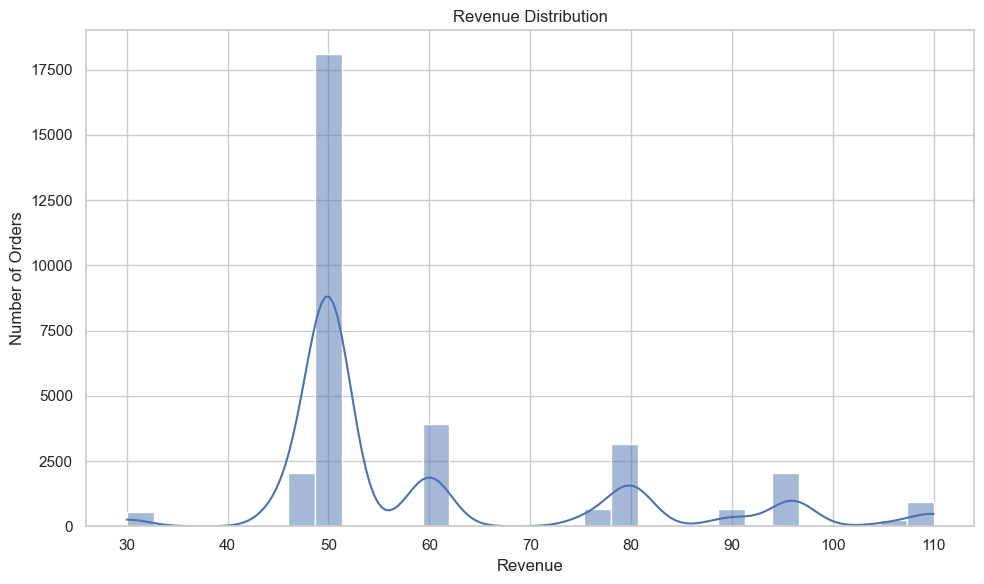

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    orders_analysis["revenue"],
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../visualizations/revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

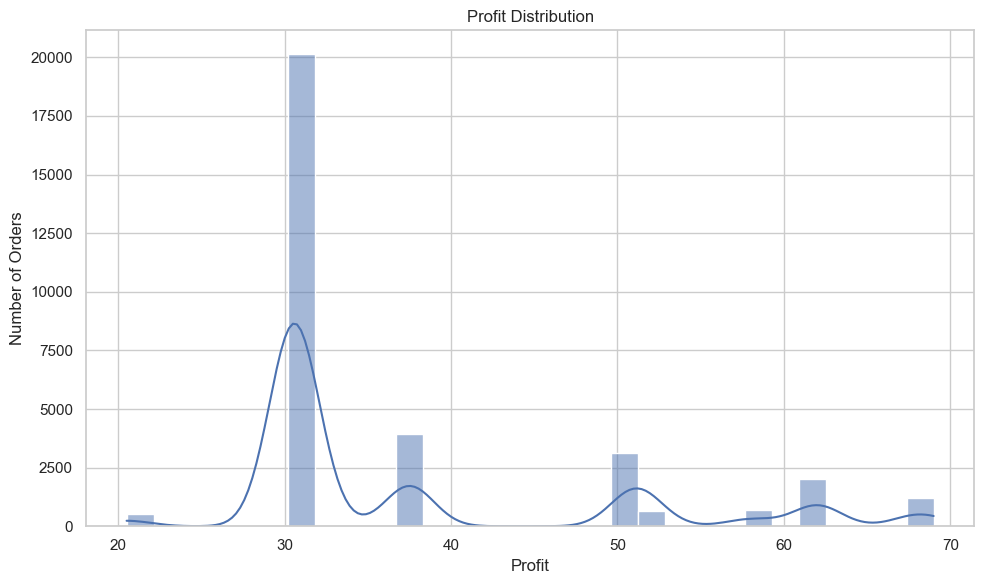

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    orders_analysis["profit"],
    bins=30,
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../visualizations/profit_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

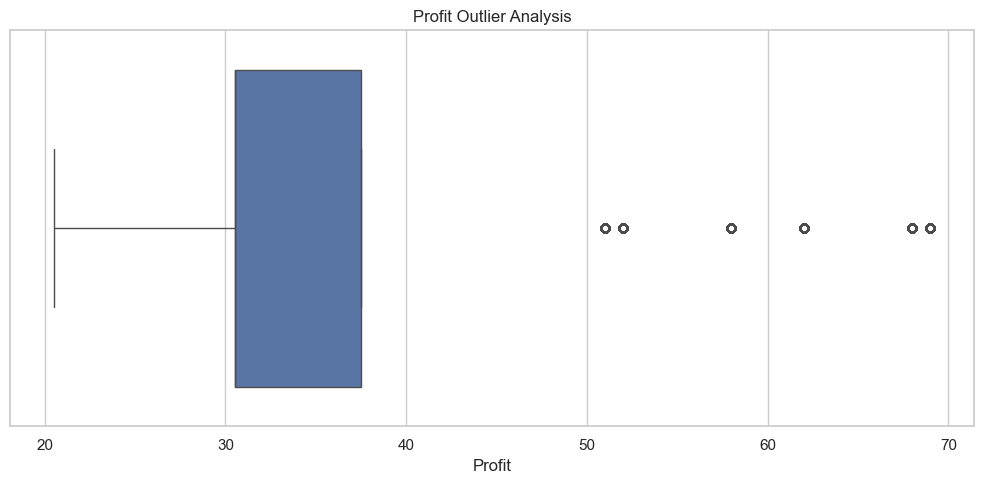

In [10]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=orders_analysis["profit"]
)

plt.title("Profit Outlier Analysis")
plt.xlabel("Profit")

plt.tight_layout()

plt.savefig(
    "../visualizations/profit_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
numeric_columns = [
    "total_items",
    "revenue",
    "cogs",
    "profit",
    "profit_margin"
]

correlation = (
    orders_analysis[numeric_columns]
    .corr()
)

display(correlation)

,total_items,revenue,cogs,profit,profit_margin
total_items,1.000000,0.919901,0.864138,0.935734,0.408865
revenue,0.919901,1.000000,0.981532,0.994825,0.253821
cogs,0.864138,0.981532,1.000000,0.957016,0.070746
profit,0.935734,0.994825,0.957016,1.000000,0.347252
profit_margin,0.408865,0.253821,0.070746,0.347252,1.000000


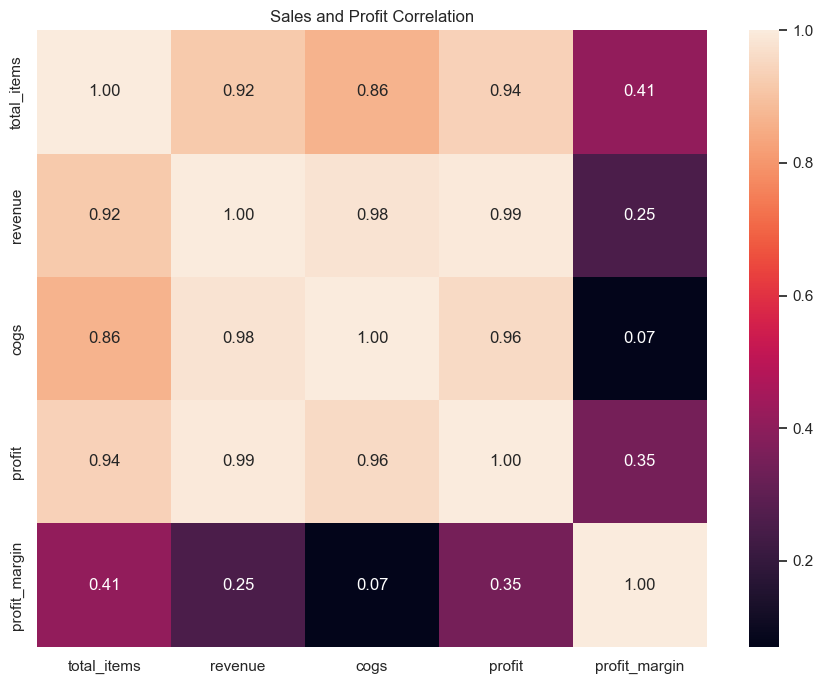

In [12]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Sales and Profit Correlation")

plt.tight_layout()

plt.savefig(
    "../visualizations/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

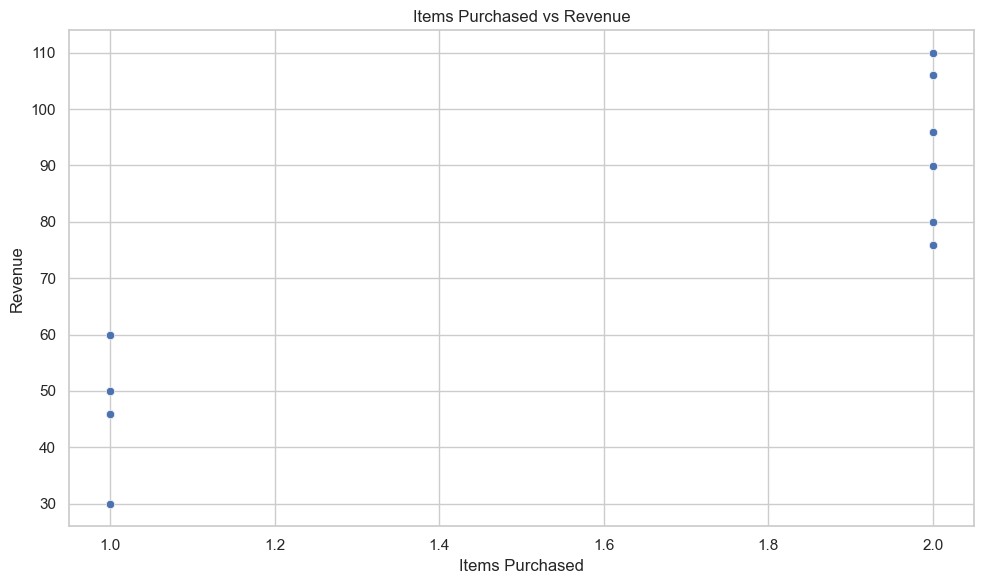

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=orders_analysis,
    x="total_items",
    y="revenue"
)

plt.title("Items Purchased vs Revenue")
plt.xlabel("Items Purchased")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "../visualizations/items_vs_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()